In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Airbnb_data.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


# EDA
Exploratory Data Analysis

In [ ]:
renameCollist={
    'id':'property_id',
    'name':'property_name',
    'number_of_reviews':'total_review',
    'calculated_host_listings_count':'host_listing_count'
}

In [ ]:
df.rename(columns=renameCollist,inplace=True)

In [ ]:
df

,property_id,property_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_review,last_review,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
df.columns

Index(['property_id', 'property_name', 'host_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'total_review', 'last_review',
       'reviews_per_month', 'host_listing_count', 'availability_365'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          48895 non-null  int64  
 1   property_name        48879 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48874 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_review         48895 non-null  int64  
 12  last_review          38843 non-null  object 
 13  reviews_per_month    38843 non-null  float64
 14  host_listing_count   48895 non-null  int64  
 15  availability_365     48895 non-null 

In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df['property_name'] = df['property_name'].fillna('unknown')
df['host_name'] = df['host_name'].fillna('unknown')

In [ ]:
df.drop(columns='last_review', axis=1, inplace=True)

In [ ]:
df.reviews_per_month=df.reviews_per_month.replace(to_replace=np.nan,value=0).astype('int64')

In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Basic understanding of the data

How many unique properties we are having in our new york?

In [ ]:
#nunique()
a=df.property_id.nunique()
print('The total unique properties we are having in our new york',a)

The total unique properties we are having in our new york 48895


How many neighbourhoods we are having?

In [ ]:
a=df.neighbourhood.nunique()
print("The total number of neighbourhood is",a)

The total number of neighbourhood is 221


How many neighbourhood group we are having

In [ ]:
a=df.neighbourhood_group.nunique()
print("the total number of neighbourhood group are",a)

the total number of neighbourhood group are 5


How many unique host we are having?

In [ ]:
a=df.host_id.nunique()
print('The total number of host we have are',a)

The total number of host we have are 37457


How many unique properties name we are having?

In [ ]:
a=df.property_name.nunique()
print('The total number of unique property names are',a)

The total number of unique property names are 47906


Insights:

In our NYC we are having 5 neighbourhood grp in total that consist of 221 neighbour.

In total we have 37457 host which are owning 48895 properties.

In [ ]:
df.describe()

,property_id,host_id,latitude,longitude,price,minimum_nights,total_review,reviews_per_month,host_listing_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,0.806258,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.502767,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.000000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.000000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.000000,327.000000,365.000000


Insights:

The average price of staying one night is 152 dollars.

The average night that a person stays un airbnb is 7.

The most expensive property of an Airbnb is at 10K usd.

The average reviews that a property has got 23.


In [ ]:
df.describe(include='object')

,property_name,host_name,neighbourhood_group,neighbourhood,room_type
count,48895,48895,48895,48895,48895
unique,47906,11453,5,221,3
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt
freq,18,417,21661,3920,25409


Insights:

The most popular airbnb is hiddside hotel

The most busiest host is Michael.

The most popular neighbourhood gruop manhattan

Most booking type is Entire home/apt

#  Visualisation

In [ ]:
df.columns

Index(['property_id', 'property_name', 'host_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'total_review',
       'reviews_per_month', 'host_listing_count', 'availability_365'],
      dtype='object')

Distribution of Airbnb Booking prices Range using histogram.

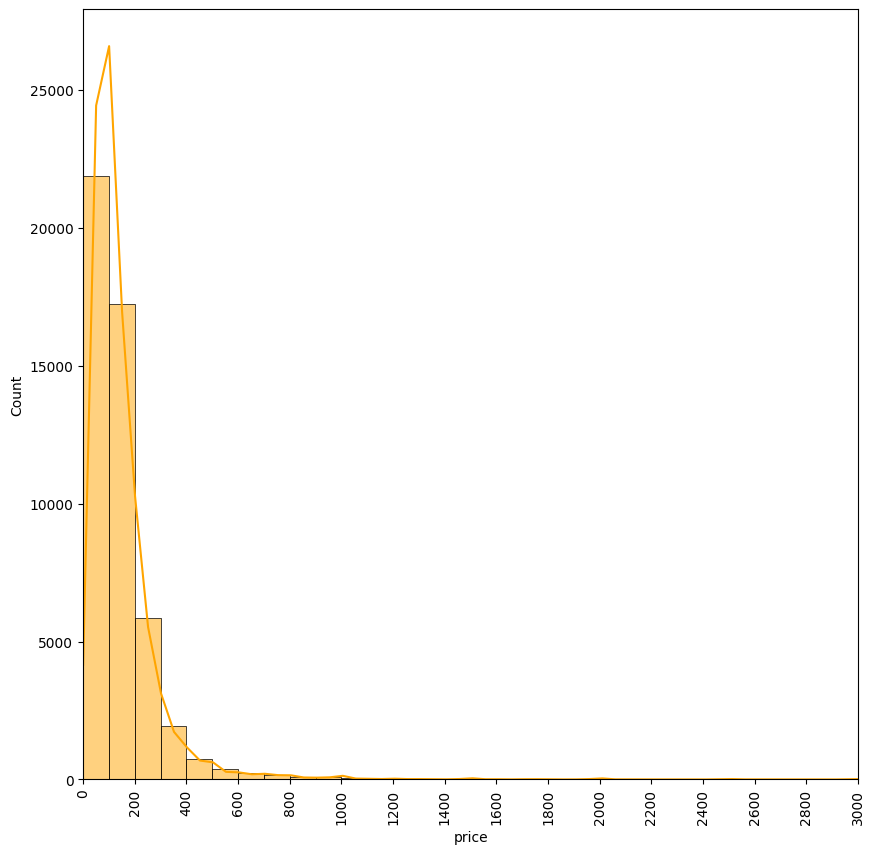

In [ ]:
plt.figure(figsize = (10,10))
sns.histplot(data=df, x='price', bins=100, color='orange',kde=True)

min_val = int(np.floor(df['price'].min() / 200) * 200)
max_val = int(np.ceil(df['price'].max() / 200) * 200)

ticks = np.arange(min_val, max_val + 1, 200)

plt.xticks(ticks, rotation=90)
plt.xlim(0,3000)
plt.show()

Insights:

Mostly prices are between 0-2000.

Low price is most prefer by people

---



Find the most busiest Neighbourhood group.

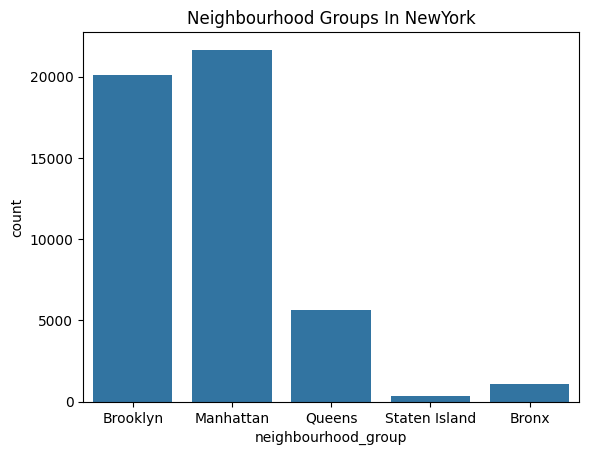

In [ ]:
sns.countplot(data=df, x='neighbourhood_group')
plt.title('Neighbourhood Groups In NewYork')
plt.show()

Insights:

Most busiest neighbourhood_group is manhattan

Least busiest neighbour_hood group is staten island

---



What is average price by room type

In [ ]:
df1 = df.groupby('room_type')['price'].mean().sort_values(ascending=False).reset_index()
df1

,room_type,price
0,Entire home/apt,211.794246
1,Private room,89.780973
2,Shared room,70.127586


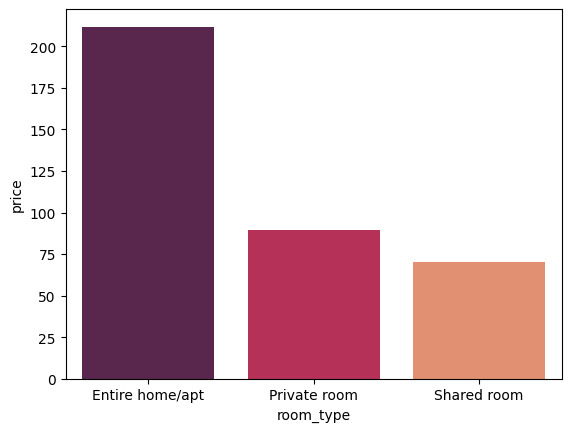

In [ ]:
sns.barplot(data=df1, y='price', x='room_type', hue='room_type', palette='rocket', legend=False)
plt.show()

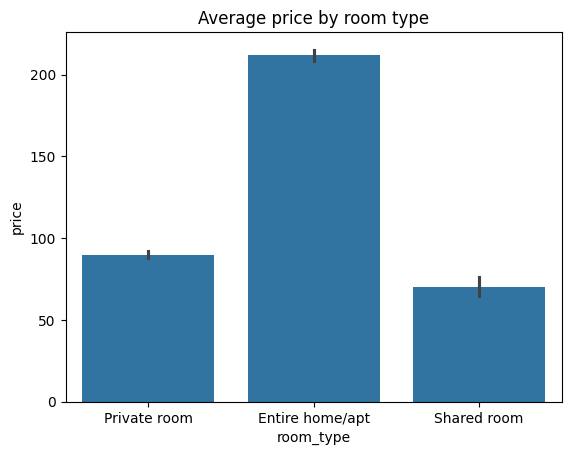

In [ ]:
sns.barplot(data=df,x='room_type',y='price')
plt.title('Average price by room type')
plt.show()